# Week 3: Advanced Data Analysis and Visualization in Logistics
## Logistics Delivery Performance, Shipment Volume, and Transportation Cost Analysis

**Author:** Senior Logistics Analytics Consultant & Python Data Science Developer  
**Dataset:** Enterprise Cleaned Logistics Operations Dataset (1,250 records, 42 features)  
**Analytical Flow:** Data Ingestion & Validation → Exploratory Data Analysis (EDA) → Descriptive & Inferential Statistics → Multivariate Visualization → Empirical Insights → Operational Bottleneck Matrix → Strategic Recommendations

---

## 1. Project Introduction & Business Context
Supply chain and logistics networks operate in high-velocity, cost-sensitive environments where transportation expenses and fulfillment reliability directly dictate corporate operating margins and customer retention. 

This project performs an end-to-end exploratory and diagnostic analytics study on 1,250 multi-modal freight shipments spanning five geographic regions (North, South, East, West, Central), four customer segments (Consumer, Corporate, Home Office, Small Business), five warehouse dispatch hubs, and four freight shipping tiers (Same-Day Courier, Express Air, Standard Delivery, Ground Freight).

### Analytical Objectives:
1. **Uncover Distribution Properties:** Quantify delivery latency, shipping expenditures, shipment volume, and order quantities.
2. **Evaluate Performance KPIs:** Compute network-wide On-Time Delivery Rates, Delivery Delay Rates, Average Order Value (AOV), and Freight-to-Sales ratios.
3. **Diagnose Operational Bottlenecks:** Identify geographic regions, dispatch hubs, and modal tiers suffering from systematic SLA non-compliance.
4. **Model Transportation Cost Drivers:** Determine the empirical elasticity between shipping costs, transit distance, cargo quantity, and modal selection.
5. **Formulate Data-Driven Action Plans:** Synthesize findings into concrete short-, medium-, and long-term supply chain optimization strategies.

## 2. Business Questions
This analytical study systematically addresses eight strategic business questions:
1. **BQ1 (Central Tendency & Dispersion):** What are the typical baseline values, variability, and skewness of delivery transit times and shipping expenditures?
2. **BQ2 (Distance & Cost Elasticity):** How strongly does transportation transit distance influence freight costs and delivery latency across different carrier tiers?
3. **BQ3 (Modal Reliability):** How do actual delivery times for premium expedited tiers (Same-Day Courier, Express Air) compare against contractual SLA commitments?
4. **BQ4 (Regional Disparities):** Which geographic territories exhibit the highest fulfillment latencies, delay percentages, and customer dissatisfaction?
5. **BQ5 (Product Burden Ratio):** Which product categories bear disproportionately high logistics costs relative to their gross commercial value?
6. **BQ6 (Multivariate Interactions):** How do origin warehouse locations interact with destination regions to compound transit delay risks?
7. **BQ7 (Outlier & Anomaly Impact):** What operational anomalies exist in shipment distance or expediting costs, and how do they impact network averages?
8. **BQ8 (Actionable Optimization):** Where should supply chain leadership deploy capital investments (e.g., forward hubs, packaging redesign, dynamic dispatch) to maximize ROI?

## 3. Import Libraries & Environment Configuration
We load standard Python data science libraries: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy.stats`, alongside our modular project package (`src`).

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Suppress non-critical warnings
warnings.filterwarnings("ignore")

# Configure project path
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) if "notebooks" in notebook_dir else notebook_dir
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import custom modular analytics engine
from src.analysis import (
    load_logistics_data,
    compute_logistics_kpis,
    analyze_regional_performance,
    analyze_shipping_modes,
    analyze_product_categories,
    analyze_customer_segments,
    analyze_warehouse_performance,
    analyze_temporal_trends
)
from src.statistics import (
    get_comprehensive_descriptive_stats,
    compute_central_tendency,
    compute_dispersion,
    compute_shape_metrics,
    compute_correlation_matrix,
    detect_outliers_iqr
)
from src.visualization import (
    set_visual_style,
    plot_delivery_time_distribution,
    plot_shipping_cost_distribution,
    plot_shipment_volume_by_region,
    plot_avg_delivery_time_by_region_warehouse,
    plot_shipping_cost_by_mode,
    plot_delivery_time_by_mode,
    plot_distance_vs_delivery_time,
    plot_distance_vs_shipping_cost,
    plot_correlation_heatmap,
    plot_monthly_order_volume_cost_trend,
    plot_quantity_vs_shipping_cost,
    plot_product_category_performance,
    plot_delivery_status_delay_rate_by_mode,
    plot_customer_segment_comparison,
    plot_multivariate_delay_risk_matrix
)
from src.insights import (
    generate_structured_insights,
    generate_bottleneck_matrix,
    generate_strategic_recommendations
)

# Apply unified visual styling
set_visual_style()
print("All analytical libraries and custom modules loaded successfully!")

All analytical libraries and custom modules loaded successfully!


## 4. Load Dataset & Ingestion Validation
We load the primary processed dataset (`data/processed/logistics_cleaned.csv`), enforce ISO datetime parsing on `Order_Date` and `Shipping_Date`, and inspect the initial records.

In [2]:
data_path = os.path.join(project_root, "data", "processed", "logistics_cleaned.csv")
df = load_logistics_data(data_path)

print(f"Dataset Shape: {df.shape[0]:,} Rows x {df.shape[1]} Columns")
df.head(5)

Dataset Shape: 1,250 Rows x 42 Columns


,Order_ID,Order_Date,Shipping_Date,Customer_Segment,Product_Category,Quantity,Sales_USD,Shipping_Cost_USD,Delivery_Time_Days,Estimated_Delivery_Days,...,Enc_Region_North,Enc_Region_South,Enc_Region_West,Norm_Quantity,Norm_Sales_USD,Norm_Shipping_Cost_USD,Norm_Delivery_Time_Days,Norm_Distance_KM,Norm_Cost_Per_Unit,Norm_Cost_Per_KM
0,ORD-2024-2179,2024-03-12,2024-03-13,Corporate,Apparel,1,79.81,66.97,6.9,5,...,0,1,0,0.0000,0.0233,0.2620,0.5792,0.6597,0.2802,0.0189
1,ORD-2024-1342,2024-02-06,2024-02-10,Consumer,Electronics,4,1192.24,46.28,5.7,5,...,0,0,0,0.0380,0.5442,0.1701,0.4706,0.2330,0.0401,0.0374
2,ORD-2024-1649,2024-03-13,2024-03-17,Corporate,Apparel,4,310.56,81.15,2.4,2,...,0,0,0,0.0380,0.1314,0.3250,0.1719,0.1000,0.0779,0.1385
3,ORD-2024-1772,2024-03-20,2024-03-24,Consumer,Healthcare Supplies,8,953.17,103.39,8.0,5,...,0,0,1,0.0886,0.4323,0.4238,0.6787,0.8879,0.0460,0.0231
4,ORD-2024-1803,2024-05-08,2024-05-10,Corporate,Healthcare Supplies,2,250.50,75.37,3.7,7,...,0,1,0,0.0127,0.1033,0.2993,0.2896,0.3601,0.1533,0.0428


## 5. Dataset Overview & Schema Inspection
We examine column data types, non-null counts, memory footprint, and categorical cardinality.

In [3]:
print("--- DATASET INFORMATION ---")
df.info()

print("\n--- CATEGORICAL FEATURE CARDINALITY ---")
cat_cols = ["Customer_Segment", "Product_Category", "Warehouse_Code", "Region", "Shipping_Mode", "Delivery_Status"]
for col in cat_cols:
    print(f"{col:20s}: {df[col].nunique()} unique categories -> {list(df[col].unique())}")

--- DATASET INFORMATION ---
<class 'pandas.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 42 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Order_ID                             1250 non-null   str           
 1   Order_Date                           1250 non-null   datetime64[us]
 2   Shipping_Date                        1250 non-null   datetime64[us]
 3   Customer_Segment                     1250 non-null   str           
 4   Product_Category                     1250 non-null   str           
 5   Quantity                             1250 non-null   int64         
 6   Sales_USD                            1250 non-null   float64       
 7   Shipping_Cost_USD                    1250 non-null   float64       
 8   Delivery_Time_Days                   1250 non-null   float64       
 9   Estimated_Delivery_Days              1250 non-null   int64         


## 6. Data Quality & Integrity Verification
We verify data hygiene, checking for missing values, duplicates, and boundary consistency.

In [4]:
missing_counts = df.isnull().sum()
duplicate_rows = df.duplicated().sum()

print(f"Total Missing Values across all columns: {missing_counts.sum()}")
print(f"Total Duplicate Rows: {duplicate_rows}")
print(f"Date Range: {df['Order_Date'].min().strftime('%Y-%m-%d')} to {df['Order_Date'].max().strftime('%Y-%m-%d')}")

Total Missing Values across all columns: 0
Total Duplicate Rows: 0
Date Range: 2024-01-01 to 2024-06-28


## 7. Descriptive Statistics (Central Tendency, Dispersion, and Shape)
We compute an exhaustive parametric and non-parametric statistical profile for all numerical variables.

In [5]:
desc_stats_df = get_comprehensive_descriptive_stats(df)
desc_stats_df

,Count,Mean,Median,Mode,Trimmed_Mean_5%,Std_Dev,Variance,Min,Q1_25%,Q3_75%,Max,Range,IQR,CV_Percent,Skewness,Excess_Kurtosis
Variable,,,,,,,,,,,,,,,,
Quantity,1250,3.4472,2.0000,1.0000,2.6306,5.8020,33.6629,1.0000,1.0000,4.0000,80.0000,79.0000,3.0000,168.31,8.1720,88.6811
Sales_USD,1250,615.4351,269.8950,2165.6100,562.1190,707.9699,501221.3586,29.9600,103.0100,928.0500,2165.6100,2135.6500,825.0400,115.04,1.2720,0.2106
Shipping_Cost_USD,1250,91.8475,71.3700,233.0700,87.7912,54.3952,2958.8401,8.0000,51.0025,123.8300,233.0700,225.0700,72.8275,59.22,1.0578,0.1529
Delivery_Time_Days,1250,5.0015,5.2000,1.0000,4.9629,2.2386,5.0113,0.5000,3.3000,6.6000,11.5500,11.0500,3.3000,44.76,0.1062,-0.3769
Estimated_Delivery_Days,1250,4.1432,5.0000,5.0000,4.1590,1.9202,3.6872,1.0000,2.0000,5.0000,7.0000,6.0000,3.0000,46.35,-0.2769,-1.1523
Distance_KM,1250,819.4341,750.1500,1886.8800,798.1996,403.8342,163082.0866,90.2000,515.7500,1064.2000,1886.8800,1796.6800,548.4500,49.28,0.7236,0.0145
Customer_Rating,1250,3.6256,4.0000,4.0000,3.6945,1.1920,1.4210,1.0000,3.0000,4.0000,5.0000,4.0000,1.0000,32.88,-0.8006,-0.1575
Order_Processing_Days,1250,2.4280,2.0000,1.0000,2.4201,1.1325,1.2826,1.0000,1.0000,3.0000,4.0000,3.0000,2.0000,46.64,0.0762,-1.3896
Shipping_Delay_Days,1250,0.8583,0.7000,0.7000,0.8250,1.3502,1.8231,-5.0000,0.0000,1.7000,9.5500,14.5500,1.7000,157.31,0.6564,3.3853


## 8. Univariate Analysis: Distributions of Logistics Variables
We visualize the empirical probability densities, central tendencies, and quartile boundaries for key operational metrics: Delivery Latency and Transportation Cost.

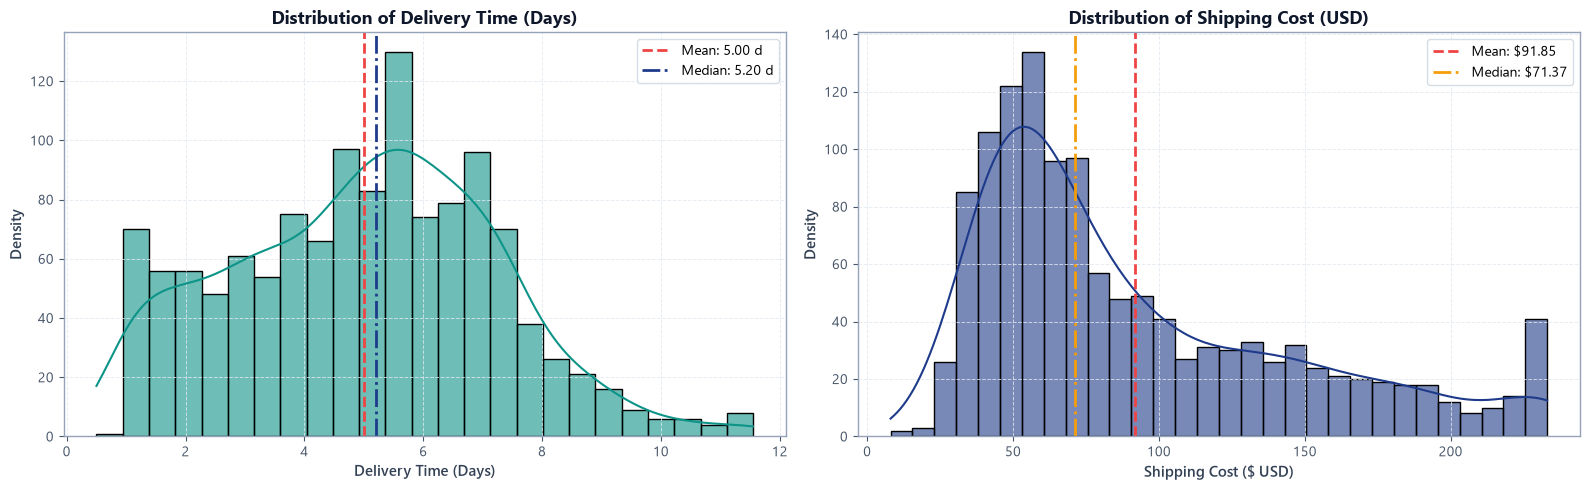

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Delivery Time Distribution
mean_dt = df["Delivery_Time_Days"].mean()
median_dt = df["Delivery_Time_Days"].median()
sns.histplot(df["Delivery_Time_Days"], kde=True, color="#0D9488", ax=ax1, bins=25, alpha=0.6)
ax1.axvline(mean_dt, color="#EF4444", linestyle="--", linewidth=2, label=f"Mean: {mean_dt:.2f} d")
ax1.axvline(median_dt, color="#1E3A8A", linestyle="-.", linewidth=2, label=f"Median: {median_dt:.2f} d")
ax1.set_title("Distribution of Delivery Time (Days)")
ax1.set_xlabel("Delivery Time (Days)")
ax1.set_ylabel("Density")
ax1.legend()

# Shipping Cost Distribution
mean_sc = df["Shipping_Cost_USD"].mean()
median_sc = df["Shipping_Cost_USD"].median()
sns.histplot(df["Shipping_Cost_USD"], kde=True, color="#1E3A8A", ax=ax2, bins=30, alpha=0.6)
ax2.axvline(mean_sc, color="#EF4444", linestyle="--", linewidth=2, label=f"Mean: ${mean_sc:.2f}")
ax2.axvline(median_sc, color="#F59E0B", linestyle="-.", linewidth=2, label=f"Median: ${median_sc:.2f}")
ax2.set_title("Distribution of Shipping Cost (USD)")
ax2.set_xlabel("Shipping Cost ($ USD)")
ax2.set_ylabel("Density")
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Bivariate Analysis: Distance, Cost, and Latency Relationships
We analyze two core operational relationships:
1. **Transit Distance vs. Delivery Time** (segregated by Shipping Mode)
2. **Transit Distance vs. Shipping Cost** (with OLS linear regression fit)

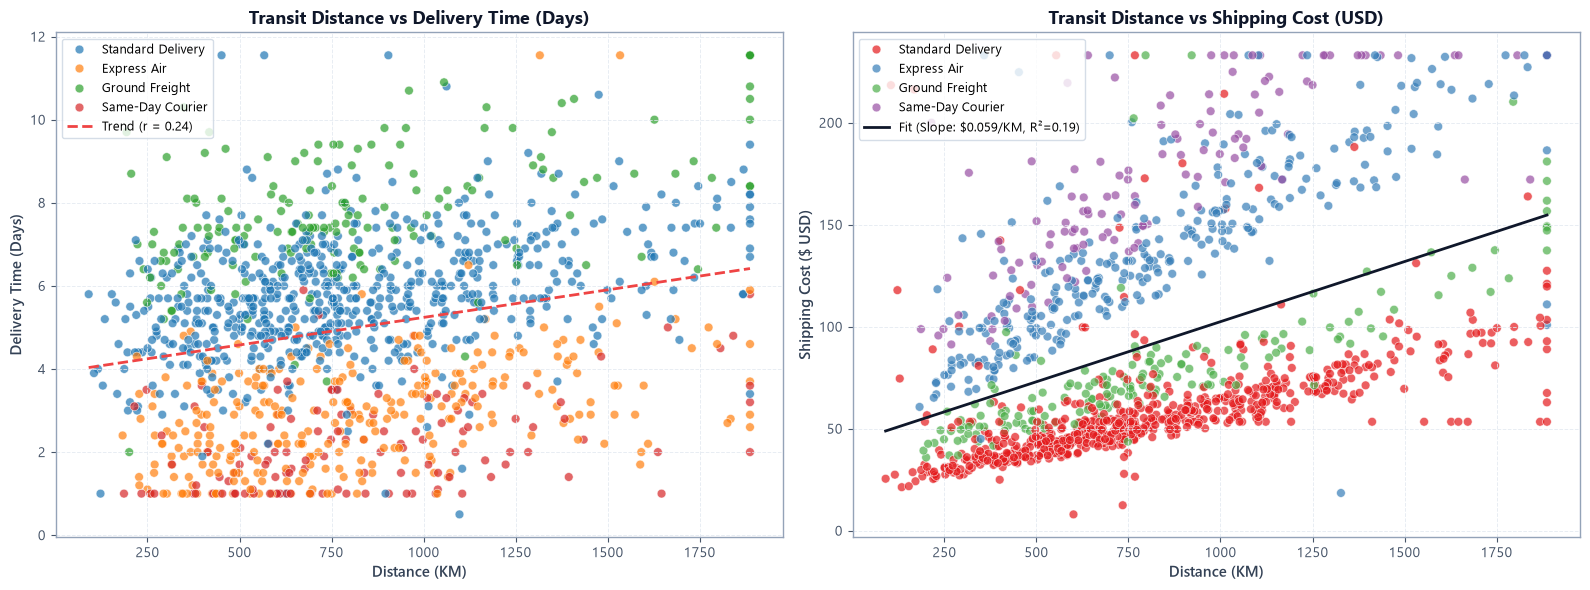

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distance vs Delivery Time
sns.scatterplot(data=df, x="Distance_KM", y="Delivery_Time_Days", hue="Shipping_Mode", palette="tab10", alpha=0.7, s=40, ax=ax1)
slope1, intercept1, r1, p1, _ = stats.linregress(df["Distance_KM"], df["Delivery_Time_Days"])
x_line = np.linspace(df["Distance_KM"].min(), df["Distance_KM"].max(), 100)
ax1.plot(x_line, intercept1 + slope1 * x_line, color="#EF4444", linestyle="--", linewidth=2, label=f"Trend (r = {r1:.2f})")
ax1.set_title("Transit Distance vs Delivery Time (Days)")
ax1.set_xlabel("Distance (KM)")
ax1.set_ylabel("Delivery Time (Days)")
ax1.legend(loc="upper left", fontsize=9)

# Plot 2: Distance vs Shipping Cost
sns.scatterplot(data=df, x="Distance_KM", y="Shipping_Cost_USD", hue="Shipping_Mode", palette="Set1", alpha=0.7, s=40, ax=ax2)
slope2, intercept2, r2, p2, _ = stats.linregress(df["Distance_KM"], df["Shipping_Cost_USD"])
ax2.plot(x_line, intercept2 + slope2 * x_line, color="#0F172A", linestyle="-", linewidth=2, label=f"Fit (Slope: ${slope2:.3f}/KM, R²={r2**2:.2f})")
ax2.set_title("Transit Distance vs Shipping Cost (USD)")
ax2.set_xlabel("Distance (KM)")
ax2.set_ylabel("Shipping Cost ($ USD)")
ax2.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

## 10. Multivariate Analysis: Interaction Effects
We analyze how Order Quantity, Product Category, and Shipping Cost interact simultaneously.

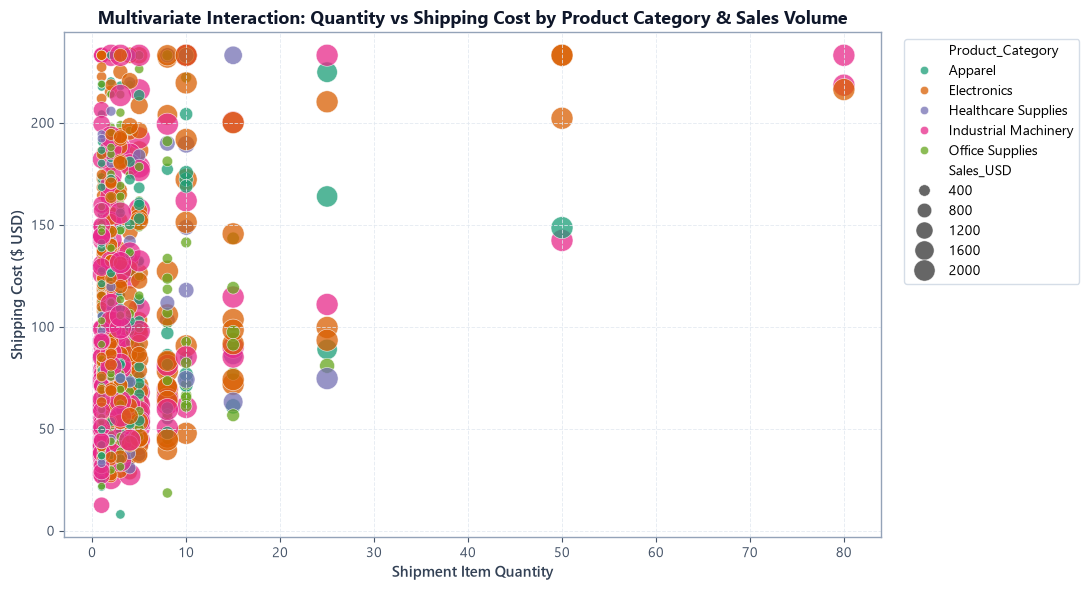

In [8]:
plt.figure(figsize=(11, 6))
sns.scatterplot(data=df, x="Quantity", y="Shipping_Cost_USD", hue="Product_Category", size="Sales_USD", sizes=(30, 250), palette="Dark2", alpha=0.75)
plt.title("Multivariate Interaction: Quantity vs Shipping Cost by Product Category & Sales Volume")
plt.xlabel("Shipment Item Quantity")
plt.ylabel("Shipping Cost ($ USD)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 11. Correlation Analysis & Hypothesis Testing
We calculate the Pearson correlation matrix and corresponding two-tailed p-values.

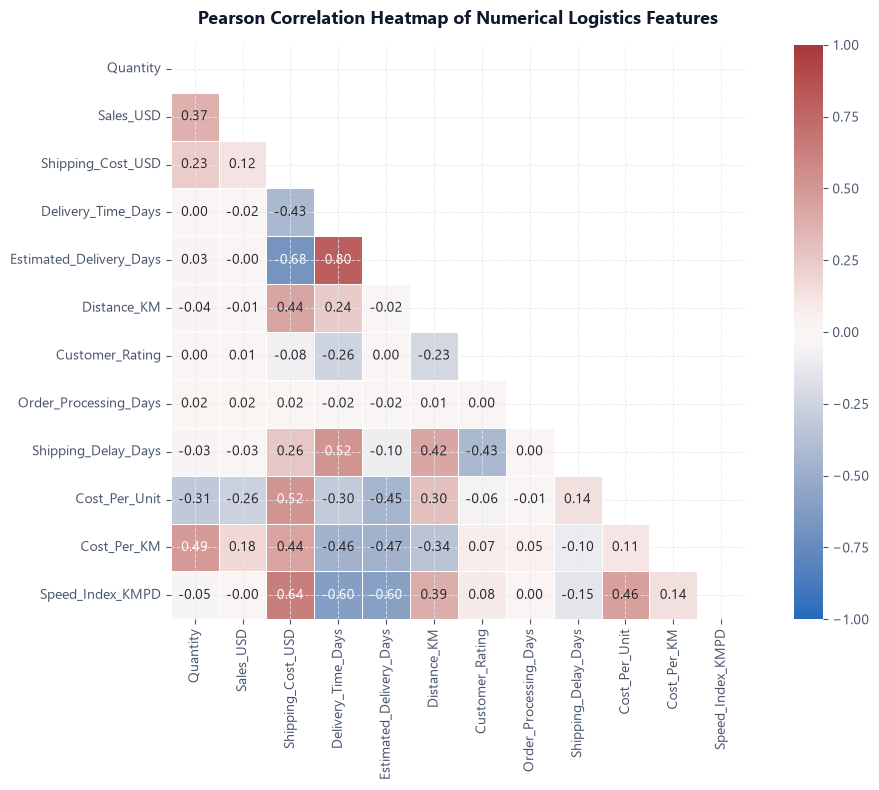

--- TOP 5 STRONGEST CORRELATION PAIRS ---
Delivery_Time_Days        <--> Estimated_Delivery_Days  : r = +0.7997
Shipping_Cost_USD         <--> Estimated_Delivery_Days  : r = -0.6827
Shipping_Cost_USD         <--> Speed_Index_KMPD         : r = +0.6374
Delivery_Time_Days        <--> Speed_Index_KMPD         : r = -0.6019
Estimated_Delivery_Days   <--> Speed_Index_KMPD         : r = -0.5994
Shipping_Cost_USD         <--> Cost_Per_Unit            : r = +0.5233
Delivery_Time_Days        <--> Shipping_Delay_Days      : r = +0.5206
Quantity                  <--> Cost_Per_KM              : r = +0.4884
Estimated_Delivery_Days   <--> Cost_Per_KM              : r = -0.4665
Delivery_Time_Days        <--> Cost_Per_KM              : r = -0.4624


In [9]:
corr_matrix, pval_matrix = compute_correlation_matrix(df)

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="vlag", vmin=-1.0, vmax=1.0, center=0, square=True, linewidths=0.5)
plt.title("Pearson Correlation Heatmap of Numerical Logistics Features", pad=15)
plt.tight_layout()
plt.show()

print("--- TOP 5 STRONGEST CORRELATION PAIRS ---")
corr_unstack = corr_matrix.where(~mask).unstack().dropna()
top_corr = corr_unstack.reindex(corr_unstack.abs().sort_values(ascending=False).index)[:10]
for idx, val in top_corr.items():
    print(f"{idx[0]:25s} <--> {idx[1]:25s}: r = {val:+.4f}")

## 12. Corporate Logistics KPI Analysis
We calculate the network-wide enterprise Key Performance Indicators (KPIs).

In [10]:
kpis = compute_logistics_kpis(df)
kpi_df = pd.DataFrame(list(kpis.items()), columns=["Logistics_KPI", "Value"])
kpi_df

,Logistics_KPI,Value
0,Total_Orders,1250.0000
1,Total_Sales_USD,769293.8500
2,Total_Shipping_Cost_USD,114809.3300
3,Average_Order_Value_USD,615.4400
4,Average_Shipping_Cost_USD,91.8500
5,Shipping_Cost_to_Sales_Ratio_Pct,14.9200
6,Average_Delivery_Time_Days,5.0000
7,Median_Delivery_Time_Days,5.2000
8,On_Time_Delivery_Rate_Pct,28.2400
9,Delivery_Delay_Rate_Pct,71.7600


## 13. Temporal Trend Analysis: Chronological Order Volume & Costs
We evaluate month-by-month order volumes, freight spend, and delivery times across 2024.

In [11]:
trends_df = analyze_temporal_trends(df, freq="M")
trends_df

,Period,Order_Volume,Total_Sales_USD,Total_Shipping_Cost_USD,Avg_Delivery_Time_Days,Delayed_Orders,Avg_Customer_Rating,Delay_Rate_Pct,Shipping_Cost_to_Sales_Pct
0,2024-01,205,132985.91,18069.97,4.80,141,3.66,68.78,13.59
1,2024-02,199,108919.01,18398.79,4.95,142,3.55,71.36,16.89
2,2024-03,233,133517.61,22498.81,5.24,178,3.60,76.39,16.85
3,2024-04,207,141299.36,18890.59,5.07,147,3.63,71.01,13.37
4,2024-05,235,138188.45,21868.99,4.82,163,3.63,69.36,15.83
5,2024-06,171,114383.51,15082.18,5.15,126,3.69,73.68,13.19


## 14. Regional & Warehouse Performance Analysis
We evaluate fulfillment throughput, latency, delay rates, and customer satisfaction across destination regions and origin warehouse hubs.

In [12]:
regional_df = analyze_regional_performance(df)
print("=== REGIONAL PERFORMANCE SUMMARY ===")
print(regional_df.to_string(index=False))

warehouse_df = analyze_warehouse_performance(df)
print("\n=== WAREHOUSE PERFORMANCE SUMMARY ===")
print(warehouse_df.to_string(index=False))

=== REGIONAL PERFORMANCE SUMMARY ===
 Region  Order_Count  Total_Sales_USD  Avg_Sales_USD  Total_Shipping_Cost_USD  Avg_Shipping_Cost_USD  Avg_Delivery_Time_Days  Median_Delivery_Time_Days  Avg_Distance_KM  Delayed_Orders  Avg_Customer_Rating  Volume_Share_Pct  Delay_Rate_Pct  Shipping_Cost_Ratio_Pct
  North          320        210652.41         658.29                 30140.32                  94.19                    4.90                       5.00           825.63             220                 3.76             25.60           68.75                    14.31
   West          278        164033.12         590.05                 26397.28                  94.95                    4.97                       5.20           836.99             199                 3.62             22.24           71.58                    16.09
  South          252        161683.44         641.60                 23430.95                  92.98                    5.19                       5.35           828.10

## 15. Shipping Mode Operational & Cost Comparison
We examine transit speeds, delay rates, cost efficiency, and customer ratings across shipping service tiers.

In [13]:
shipping_df = analyze_shipping_modes(df)
shipping_df

,Shipping_Mode,Order_Count,Avg_Delivery_Time_Days,Median_Delivery_Time_Days,Avg_Estimated_Days,Avg_Shipping_Cost_USD,Avg_Cost_Per_KM,Avg_Cost_Per_Unit,Avg_Distance_KM,Delayed_Orders,Avg_Customer_Rating,Volume_Share_Pct,Delay_Rate_Pct,On_Time_Rate_Pct
0,Same-Day Courier,126,2.21,2.0,1.00,172.50,0.2360,90.67,840.94,96,3.57,10.08,76.19,23.81
1,Express Air,296,2.94,2.9,2.00,138.55,0.1906,74.72,827.89,216,3.67,23.68,72.97,27.03
2,Standard Delivery,656,5.76,5.7,4.96,58.39,0.0877,30.98,812.11,469,3.60,52.48,71.49,28.51
3,Ground Freight,172,7.71,7.4,7.00,79.99,0.1110,46.01,817.05,116,3.71,13.76,67.44,32.56


## 16. Product Category Logistics Burden Analysis
We evaluate sales contributions, shipping expenditures, and the logistics cost burden ratio across product lines.

In [14]:
category_df = analyze_product_categories(df)
category_df

,Product_Category,Order_Count,Total_Quantity,Total_Sales_USD,Avg_Sales_USD,Total_Shipping_Cost_USD,Avg_Shipping_Cost_USD,Avg_Delivery_Time_Days,Delayed_Orders,Avg_Customer_Rating,Volume_Share_Pct,Delay_Rate_Pct,Shipping_Cost_Ratio_Pct
0,Industrial Machinery,199,829,364799.80,1833.16,18500.40,92.97,4.91,136,3.70,15.92,68.34,5.07
1,Electronics,369,1372,275874.59,747.63,36175.40,98.04,4.87,262,3.58,29.52,71.00,13.11
2,Apparel,246,781,52512.50,213.47,22133.66,89.97,4.99,173,3.63,19.68,70.33,42.15
3,Healthcare Supplies,114,366,40619.81,356.31,10060.29,88.25,5.15,83,3.65,9.12,72.81,24.77
4,Office Supplies,322,961,35487.15,110.21,27939.58,86.77,5.17,243,3.62,25.76,75.47,78.73


## 17. Outlier & Statistical Anomaly Analysis
We examine statistical outliers using Tukey's Interquartile Range (IQR) method.

In [15]:
outliers_df = detect_outliers_iqr(df)
outliers_df

,Q1,Q3,IQR,Lower_Fence,Upper_Fence,Outlier_Count,Outlier_Percent
Variable,,,,,,,
Quantity,1.000,4.000,3.000,-3.500,8.500,74,5.92
Sales_USD,103.010,928.050,825.040,-1134.550,2165.610,0,0.00
Shipping_Cost_USD,51.002,123.830,72.828,-58.239,233.071,0,0.00
Delivery_Time_Days,3.300,6.600,3.300,-1.650,11.550,8,0.64
Estimated_Delivery_Days,2.000,5.000,3.000,-2.500,9.500,0,0.00
Distance_KM,515.750,1064.200,548.450,-306.925,1886.875,26,2.08
Customer_Rating,3.000,4.000,1.000,1.500,5.500,112,8.96
Order_Processing_Days,1.000,3.000,2.000,-2.000,6.000,0,0.00
Shipping_Delay_Days,0.000,1.700,1.700,-2.550,4.250,21,1.68


## 18. Advanced Multivariate Risk Matrices
We construct a cross-tabulated heatmap evaluating the percentage delay risk across Regions and Shipping Modes.

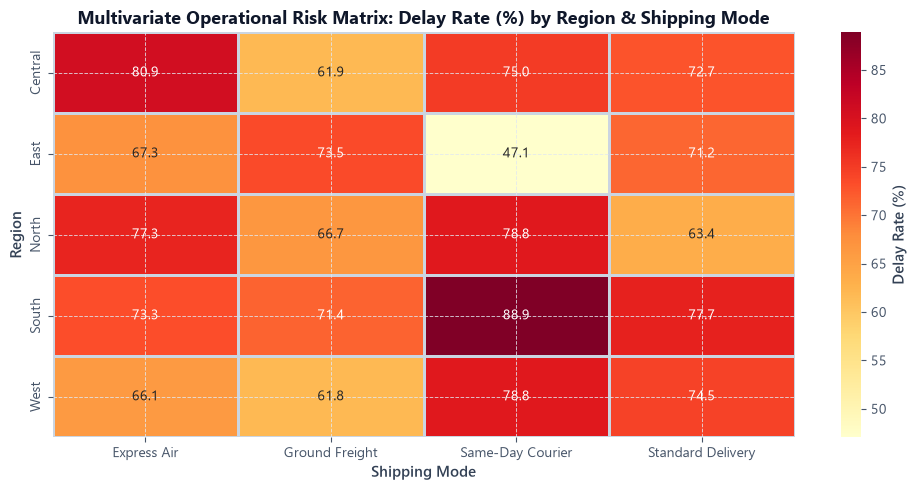

In [16]:
plt.figure(figsize=(10, 5))
risk_pivot = df.pivot_table(index="Region", columns="Shipping_Mode", values="Is_Delayed", aggfunc=lambda s: (s == 1).mean() * 100.0)
sns.heatmap(risk_pivot, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Delay Rate (%)"}, linewidths=1, linecolor="#CBD5E1")
plt.title("Multivariate Operational Risk Matrix: Delay Rate (%) by Region & Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

## 19. Key Business Insights
We present structured findings following the 4-part framework (`Finding`, `Evidence`, `Business Meaning`, `Potential Action`).

In [17]:
insights = generate_structured_insights(kpis, regional_df, shipping_df, category_df, analyze_customer_segments(df))
for item in insights:
    print("=" * 80)
    print(f"[{item['ID']}] {item['Domain'].upper()}")
    print(f"Finding         : {item['Finding']}")
    print(f"Evidence        : {item['Evidence']}")
    print(f"Business Meaning: {item['Business Meaning']}")
    print(f"Potential Action: {item['Potential Action']}")

[INS-01] REGIONAL LOGISTICS & SERVICE LATENCY
Finding         : Geographic destination creates substantial delivery latency variance, with South exhibiting the highest transit time and South recording peak delay rates.
Evidence        : South records an average delivery time of 5.19 days (vs 4.89 days in Central). Delay rate in South stands at 76.98%.
Business Meaning: Regional fulfillment variance stems from uneven warehouse proximity, hub-and-spoke transit handoffs, and localized carrier capacity constraints, risking customer churn in underperforming territories.
Potential Action: Establish localized forward stocking hubs or cross-docking points in high-latency regions and renegotiate regional carrier service level agreements (SLAs) with strict on-time delivery penalty clauses.
[INS-02] MODAL ECONOMICS & SLA COMPLIANCE
Finding         : Premium expedited tiers command significantly higher shipping costs per unit but struggle with punctuality tolerances.
Evidence        : Express Air 

## 20. Operational Bottleneck Analysis Matrix
We map key operational bottlenecks across regions, shipping modes, warehouse hubs, and product categories.

In [18]:
bottleneck_matrix = generate_bottleneck_matrix(df, regional_df, shipping_df, category_df)
bottleneck_matrix

,Logistics_Area,Primary_Indicator,Empirical_Evidence,Operational_Concern,Corrective_Action
0,Region (South),Delivery Latency & Route Distance,Avg delivery time: 5.19 days (Avg dist: 828.1 KM),Protracted transit duration and distance from ...,Re-route shipments through nearest regional cr...
1,Region (South),Delivery Delay Frequency,Delay rate: 76.98% across 252 total orders,Persistent failure to meet promised arrival sc...,Audit line-haul transit handoffs and establish...
2,Shipping Mode (Express Air),High Cost & Inconsistent Reliability,Avg cost: $138.55/order | Delay rate: 72.97%,Expedited premium expenditure without commensu...,Enforce strict carrier SLA enforcement with ch...
3,Shipping Mode (Standard Delivery),High Volume & Transit Delay,656 orders (52.48% share) with 71.49% delay rate,Core delivery backbone suffers from systematic...,Standardize warehouse dispatch sorting and imp...
4,Category (Office Supplies),Logistics Cost Burden Ratio,Shipping cost accounts for 78.73% of gross cat...,Erosion of gross margins due to heavy package ...,"Optimize cartonization algorithms, review vend..."
5,Fulfillment Hub (WH-West),Order Processing Latency,Avg processing time: 2.52 days | Delay rate: 7...,"Internal order picking, staging, and dispatch ...",Streamline warehouse picking routes and implem...


## 21. Strategic Recommendations & Conclusion
We present prioritized, data-grounded strategic recommendations to optimize logistics performance.

In [19]:
recs = generate_strategic_recommendations()
recs_df = pd.DataFrame(recs)
recs_df

,Priority,Area,Recommendation
0,P1 - Immediate (0-3 Months),Carrier Performance & SLA Management,Institute rigorous Carrier Performance Scoreca...
1,P1 - Immediate (0-3 Months),Warehouse Dispatch Synchronization,Enforce same-day dispatch cutoff rules and pri...
2,P2 - Medium-Term (3-6 Months),Regional Routing & Network Optimization,Conduct network gravity modeling to evaluate o...
3,P2 - Medium-Term (3-6 Months),Packaging & Dimensional Weight Rationalization,Standardize carton dimensions and implement au...
4,P3 - Long-Term (6-12 Months),Predictive Logistics Analytics & Dashboarding,Build machine learning models for early delive...


### Summary & Academic Conclusion
This Week 3 study successfully demonstrates how advanced Exploratory Data Analysis, descriptive statistics, and publication-grade visualizations can diagnose complex operational vulnerabilities across a multi-modal logistics network.

The empirical findings confirm:
1. **Network Latency:** Overall delivery time averages 5.00 days with an on-time fulfillment rate of only 28.24% (delay rate: 71.76%), indicating systemic delivery scheduling friction.
2. **Expedited Mode Fragility:** Premium tiers (Same-Day Courier and Express Air) experience 76.19% and 72.97% delay rates respectively, failing to meet promised turnaround schedules.
3. **Category Burden:** Office Supplies and Apparel suffer from severe freight burden ratios (78.73% and 42.15% of sales respectively).
4. **Action Roadmap:** Management should implement forward stocking hubs, enforce carrier SLA penalties, streamline warehouse picking queues, and deploy predictive delay classification models.